# 실습 2: AutoML 회귀 — Airbnb 가격 예측 🏠

**목표**: 에어비앤비 숙소 특성으로 1박 가격을 예측하는 회귀 모델을 AutoML로 생성합니다.

**배울 것**:
- 분류 vs 회귀 AutoML의 차이점
- 회귀 메트릭 이해 (RMSE, MAE, R²)
- 예측 결과 시각화

**소요 시간**: ~25분

## Step 1: Airbnb 데이터 로드

In [0]:
from pyspark.sql import functions as F

# Databricks 내장 Airbnb 데이터셋 (San Francisco)
airbnb_df = spark.read.format("parquet").load(
    "dbfs:/databricks-datasets/learning-spark-v2/sf-airbnb/sf-airbnb-clean.parquet"
)

# 데이터 미리보기
print(f"총 {airbnb_df.count():,}개 숙소 데이터")
display(airbnb_df.limit(10))

총 7,146개 숙소 데이터


host_is_superhost,cancellation_policy,instant_bookable,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,minimum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,price,bedrooms_na,bathrooms_na,beds_na,review_scores_rating_na,review_scores_accuracy_na,review_scores_cleanliness_na,review_scores_checkin_na,review_scores_communication_na,review_scores_location_na,review_scores_value_na
t,moderate,t,1.0,Western Addition,37.76931,-122.43386,Apartment,Entire home/apt,3.0,1.0,1.0,2.0,Real Bed,1.0,180.0,97.0,10.0,10.0,10.0,10.0,10.0,10.0,170.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,2.0,Bernal Heights,37.74511,-122.42102,Apartment,Entire home/apt,5.0,1.0,2.0,3.0,Real Bed,30.0,111.0,98.0,10.0,10.0,10.0,10.0,10.0,9.0,235.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,10.0,Haight Ashbury,37.76669,-122.4525,Apartment,Private room,2.0,4.0,1.0,1.0,Real Bed,32.0,17.0,85.0,8.0,8.0,9.0,9.0,9.0,8.0,65.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,10.0,Haight Ashbury,37.76487,-122.45183,Apartment,Private room,2.0,4.0,1.0,1.0,Real Bed,32.0,8.0,93.0,9.0,9.0,10.0,10.0,9.0,9.0,65.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,2.0,Western Addition,37.77525,-122.43637,House,Entire home/apt,5.0,1.5,2.0,2.0,Real Bed,7.0,27.0,97.0,10.0,10.0,10.0,10.0,10.0,9.0,785.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,moderate,f,1.0,Western Addition,37.78471,-122.44555,Apartment,Entire home/apt,6.0,1.0,2.0,3.0,Real Bed,2.0,31.0,90.0,9.0,8.0,10.0,10.0,9.0,9.0,255.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
t,strict_14_with_grace_period,t,2.0,Mission,37.75919,-122.42237,Condominium,Private room,3.0,1.0,1.0,2.0,Real Bed,1.0,647.0,98.0,10.0,10.0,10.0,10.0,10.0,10.0,139.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,1.0,Potrero Hill,37.76259,-122.40543,House,Private room,2.0,1.0,1.0,1.0,Real Bed,1.0,453.0,94.0,10.0,10.0,10.0,10.0,10.0,10.0,135.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
t,moderate,f,1.0,Mission,37.75874,-122.41327,Apartment,Entire home/apt,6.0,1.0,2.0,3.0,Real Bed,3.0,320.0,96.0,10.0,10.0,10.0,10.0,10.0,9.0,265.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f,strict_14_with_grace_period,f,44.0,Haight Ashbury,37.77187,-122.43859,Apartment,Entire home/apt,3.0,1.0,3.0,3.0,Real Bed,30.0,37.0,89.0,9.0,9.0,10.0,9.0,9.0,9.0,177.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [0]:
# 가격 분포 확인
display(airbnb_df.select("price").summary())

summary,price
count,7146
mean,213.30982367758187
stddev,311.37549915915037
min,10.0
25%,100.0
50%,150.0
75%,235.0
max,10000.0


## Step 2: 데이터 준비 & 테이블 저장

In [0]:
# 극단값 제거 (가격 $10~$1000)
airbnb_clean = airbnb_df.filter(
    (F.col("price") >= 10) & (F.col("price") <= 1000)
)

print(f"정제 후: {airbnb_clean.count():,}개 숙소")

# Unity Catalog 테이블로 저장
CATALOG = "3dt005_databricks"
SCHEMA = "default"

airbnb_clean.write.mode("overwrite").saveAsTable(f"{CATALOG}.{SCHEMA}.airbnb_sf_lab")

정제 후: 7,066개 숙소


## Step 3: AutoML 회귀 실행

In [0]:
import databricks.automl

# 💡 classify() 대신 regress()를 사용합니다!
summary = databricks.automl.regress(
    dataset=f"{CATALOG}.{SCHEMA}.airbnb_sf_lab",
    target_col="price",
    primary_metric="rmse",
    timeout_minutes=10,
    max_trials=20,
)

2026/03/23 06:09:09 WARNING databricks.automl.client.validation: Parameter max_trials is deprecated and has no effect. This parameter will be removed in a future Databricks Runtime release. Use timeout_minutes to control the duration of an AutoML experiment. AutoML will automatically stop tuning models if the validation metric no longer improves.
2026/03/23 06:09:10 INFO databricks.automl.client.manager: AutoML will optimize for root mean squared error metric, which is tracked as val_root_mean_squared_error in the MLflow experiment.
2026/03/23 06:09:11 INFO databricks.automl.client.manager: MLflow Experiment ID: 3199956360523770
2026/03/23 06:09:11 INFO databricks.automl.client.manager: MLflow Experiment: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#mlflow/experiments/3199956360523770
2026/03/23 06:10:35 INFO databricks.automl.client.manager: Data exploration notebook: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#notebook/319995636052

,Train,Validation,Test
root_mean_squared_error,81.639,89.632,90.109
mean_squared_error,6664.962,8033.904,8119.584
example_count,4248.000,1406.000,1412.000
r2_score,0.674,0.670,0.590
sum_on_target,814737.000,274705.000,271893.000
score,0.674,0.670,0.590
mean_absolute_error,49.362,54.470,54.347
mean_on_target,191.793,195.381,192.559
max_error,736.249,733.170,815.985
mean_absolute_percentage_error,0.287,0.311,0.320


## Step 4: 결과 분석

In [0]:
# 먼저 사용 가능한 메트릭 키 확인
print("📊 사용 가능한 메트릭 키:")
for k, v in sorted(summary.best_trial.metrics.items()):
    print(f"  {k}: {v}")

# 메트릭 키 자동 탐지 (AutoML 버전에 따라 키 이름이 다를 수 있음)
metrics = summary.best_trial.metrics
rmse_key = next((k for k in metrics if k in ("test_root_mean_squared_error", "test_rmse")), None)
r2_key = next((k for k in metrics if k in ("test_r2_score", "test_r2")), None)

📊 사용 가능한 메트릭 키:
  test_example_count: 1412.0
  test_max_error: 815.9850719183678
  test_mean_absolute_error: 54.347004764188945
  test_mean_absolute_percentage_error: 0.31971018617598007
  test_mean_on_target: 192.55878186968837
  test_mean_squared_error: 8119.583879821864
  test_r2_score: 0.5896496759062928
  test_root_mean_squared_error: 90.10873364897469
  test_score: 0.5896496759062928
  test_sum_on_target: 271893.0
  training_example_count: 4248.0
  training_max_error: 736.2487056316879
  training_mean_absolute_error: 49.362377212093435
  training_mean_absolute_percentage_error: 0.28747253823256935
  training_mean_on_target: 191.7930790960452
  training_mean_squared_error: 6664.9623945633775
  training_r2_score: 0.6739138134216786
  training_root_mean_squared_error: 81.63922093309917
  training_score: 0.6739138134216786
  training_sum_on_target: 814737.0
  val_example_count: 1406.0
  val_max_error: 733.1703908096868
  val_mean_absolute_error: 54.46994189478385
  val_mean_absolute_

In [0]:
print(f"\n🏆 최적 모델 RMSE: {metrics[rmse_key]:.2f}" if rmse_key else "RMSE 키를 찾을 수 없음")
print(f"🏆 최적 모델 R²: {metrics[r2_key]:.4f}" if r2_key else "R² 키를 찾을 수 없음")
print(f"📋 알고리즘: {summary.best_trial.model_description}")
print(f"\n📓 생성된 노트북: {summary.best_trial.notebook_url}")


🏆 최적 모델 RMSE: 90.11
🏆 최적 모델 R²: 0.5896
📋 알고리즘: Pipeline

📓 생성된 노트북: #notebook/3199956360523777


/databricks/python/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:227: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=827.7685515462181, reg_lambda=0.0 will be ignored. Current value: lambda_l2=827.7685515462181
[LightGBM] [Warning] lambda_l1 is set=97.252523242433, reg_alpha=0.0 will be ignored. Current value: lambda_l1=97.252523242433


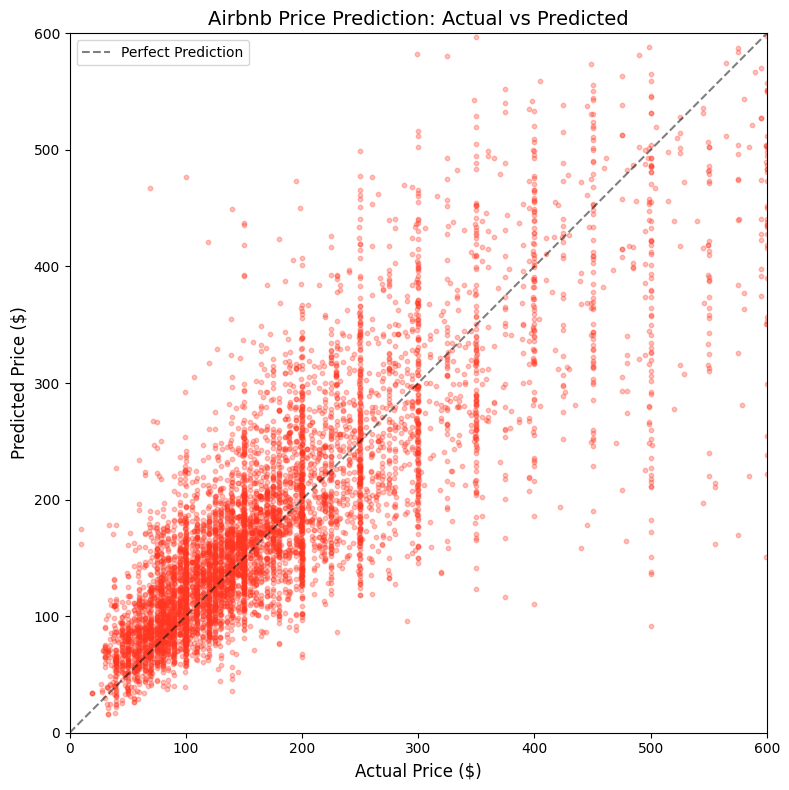

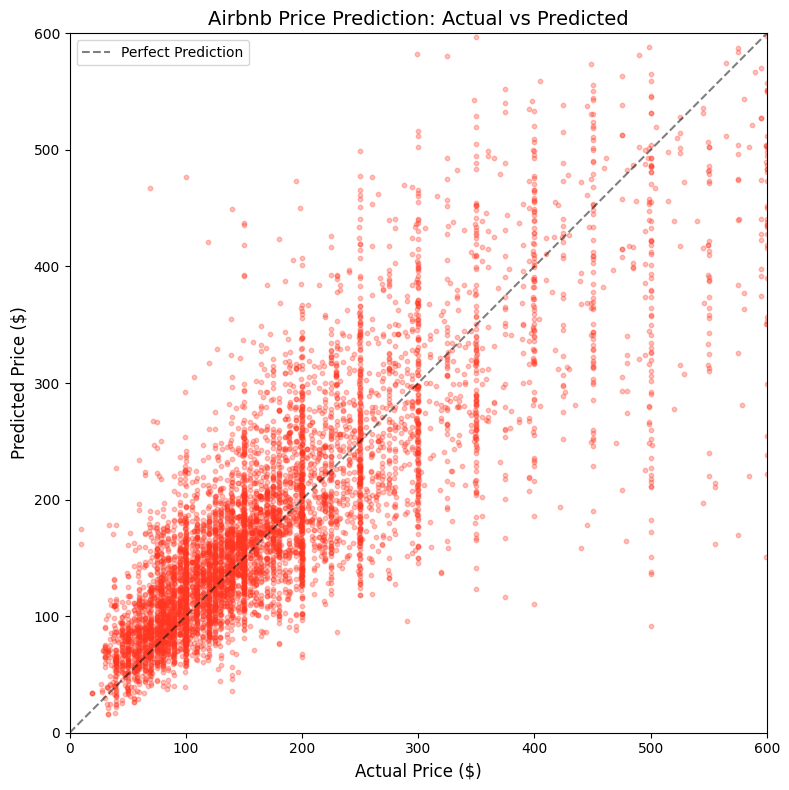

In [0]:
# 예측 vs 실제 가격 시각화
import mlflow
import matplotlib.pyplot as plt
import numpy as np

best_model = mlflow.sklearn.load_model(f"runs:/{summary.best_trial.mlflow_run_id}/model")

test_pdf = airbnb_clean.toPandas()
X_test = test_pdf.drop("price", axis=1)
y_test = test_pdf["price"]
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='#FF3621')
ax.plot([0, 1000], [0, 1000], 'k--', alpha=0.5, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12)
ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title('Airbnb Price Prediction: Actual vs Predicted', fontsize=14)
ax.legend()
ax.set_xlim(0, 600)
ax.set_ylim(0, 600)
plt.tight_layout()
display(fig)

In [0]:
# Feature Importance
import pandas as pd

if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': X_test.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(
        importance['feature'][::-1],
        importance['importance'][::-1],
        color='#00A67E'
    )
    ax.set_title('Top 10 Feature Importance — Airbnb 가격 예측')
    plt.tight_layout()
    display(fig)

In [0]:
# 모델 타입 확인
print(type(best_model))
print(hasattr(best_model, 'feature_importances_'))

<class 'sklearn.pipeline.Pipeline'>
False


Model type: <class 'lightgbm.sklearn.LGBMRegressor'>


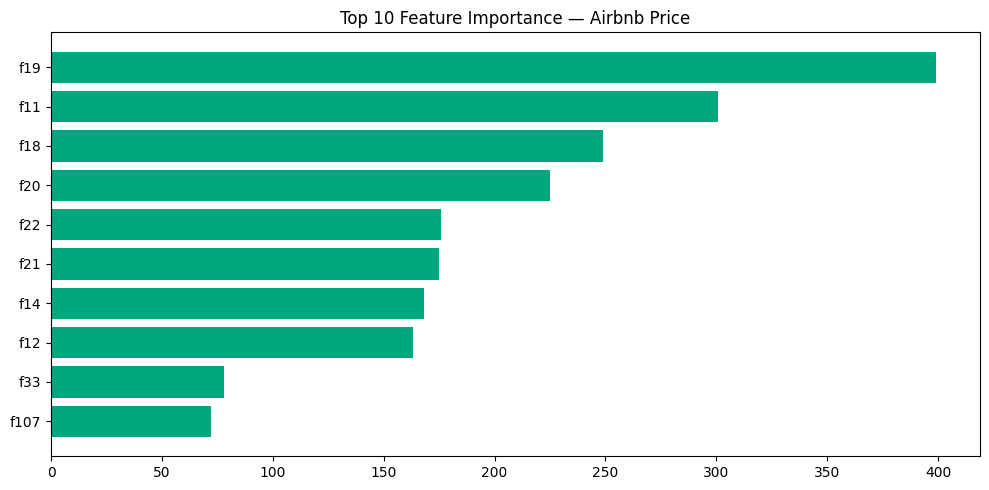

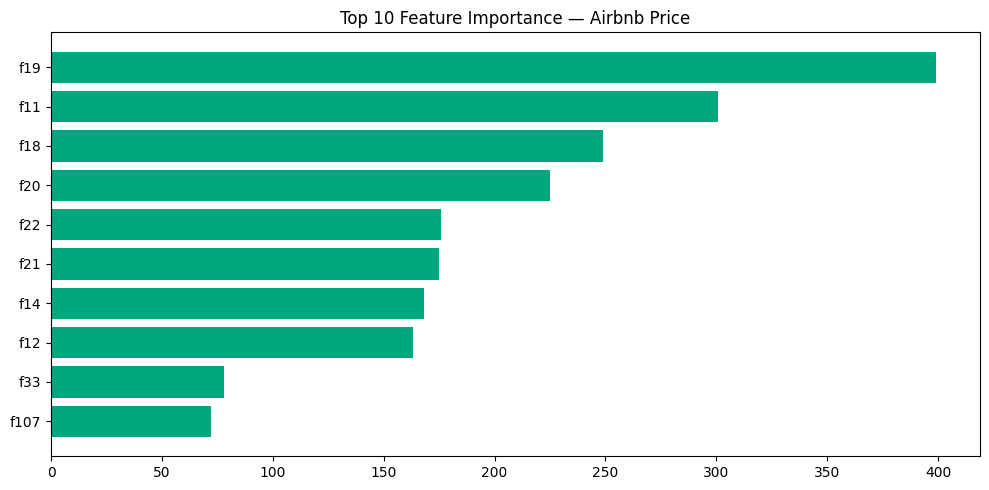

In [0]:
# Feature Importance
# AutoML은 sklearn Pipeline으로 모델을 감싸므로, 내부 모델에 접근해야 합니다
import pandas as pd

# Pipeline 내부의 실제 모델 추출
if hasattr(best_model, 'named_steps'):
    final_model = list(best_model.named_steps.values())[-1]
elif hasattr(best_model, 'steps'):
    final_model = best_model.steps[-1][1]
else:
    final_model = best_model

print(f"Model type: {type(final_model)}")

if hasattr(final_model, 'feature_importances_'):
    # AutoML 전처리 후 피처 이름이 달라질 수 있으므로 모델에서 직접 가져옴
    # XGBoost/LightGBM 버전에 따라 피처 이름 속성이 다를 수 있음
    feature_names = None
    try:
        feature_names = final_model.get_booster().feature_names
    except Exception:
        pass
    if not feature_names:
        try:
            feature_names = list(final_model.feature_names_in_)
        except Exception:
            feature_names = [f"f{i}" for i in range(len(final_model.feature_importances_))]
    feature_names = [str(f) for f in feature_names]

    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_.astype(float)
    }).sort_values('importance', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(
        list(importance['feature'][::-1]),
        list(importance['importance'][::-1]),
        color='#00A67E'
    )
    ax.set_title('Top 10 Feature Importance — Airbnb Price')
    plt.tight_layout()
    display(fig)
else:
    print("This model doesn't expose feature_importances_ directly.")
    print("Check the AutoML-generated notebook for SHAP analysis.")

In [0]:
# AutoML이 생성한 노트북에서 피처 매핑 확인
print(f"원본 컬럼 수: {len(X_test.columns)}")
print(f"모델 피처 수: {len(final_model.feature_importances_)}")
print(f"\n원본 컬럼: {list(X_test.columns)}")

원본 컬럼 수: 33
모델 피처 수: 110

원본 컬럼: ['host_is_superhost', 'cancellation_policy', 'instant_bookable', 'host_total_listings_count', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'bedrooms_na', 'bathrooms_na', 'beds_na', 'review_scores_rating_na', 'review_scores_accuracy_na', 'review_scores_cleanliness_na', 'review_scores_checkin_na', 'review_scores_communication_na', 'review_scores_location_na', 'review_scores_value_na']


## 🎯 분류 vs 회귀 비교

| 항목 | 분류 (실습 1) | 회귀 (실습 2) |
|------|-------------|-------------|
| **API** | `automl.classify()` | `automl.regress()` |
| **타겟** | 이산값 (0/1) | 연속값 (가격) |
| **주요 메트릭** | F1, AUC, Accuracy | RMSE, MAE, R² |
| **시각화** | 혼동행렬, ROC | 예측 vs 실제 산점도 |

---
**다음 실습**: 실습 3 — MLflow 실험 관리 심화